# 02 · Anatomy of a Time Series

Chapter 01 turned up patterns by eye: a daily rhythm, a winter season of severe smog, differences between years. This chapter makes that precise. We'll write a series as the combination of a few **components**, extract them, and measure how much each one matters.

**By the end of this chapter you will be able to**

- describe a series in terms of **trend**, **seasonality** and **remainder**
- tell **additive** from **multiplicative** structure, and use a log to turn one into the other
- implement a classical decomposition **from scratch**, and check it against statsmodels
- use **STL**, which allows the seasonal pattern to evolve and resists outliers
- quantify **trend strength** and **seasonal strength** so series can be compared on a single scale
- find an unknown seasonal period with the **periodogram**, and avoid its main trap

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.seasonal import STL, seasonal_decompose

import tsutils

tsutils.set_style()
pd.set_option("display.precision", 2)

---
## 1. Three components

Most series can usefully be described as a combination of:

| Component | What it captures | Example in Beijing air quality |
|---|---|---|
| **Trend** $T_t$ | slow, long-run movement in the level | gradual improvement across the 2010s |
| **Seasonality** $S_t$ | a pattern that repeats with a **fixed, known period** | the daily cycle; the heating season |
| **Remainder** $R_t$ | everything else: noise, one-off events, anything the other two miss | a week-long smog episode |

Periodic-looking behaviour whose length *isn't* fixed, like business cycles or the roughly 11-year sunspot cycle, is called a **cycle**, not seasonality. Decomposition methods need the period in advance, so cycles usually end up split between the trend and the remainder.

The components can combine in two basic ways:

$$\text{additive: } y_t = T_t + S_t + R_t \qquad\qquad \text{multiplicative: } y_t = T_t \times S_t \times R_t$$

In an additive series the seasonal swings stay the **same size** as the level changes. In a multiplicative series they **grow and shrink with the level**: a 10% seasonal bump is small when the level is 50 and large when it's 500.

---
## 2. Build a series, so we know the answer

The best way to understand a decomposition method is to feed it data where we *already know* the true components. We'll construct ten years of monthly data with a linear trend, a yearly seasonal pattern and random noise.

One detail matters more than it looks. A seasonal pattern with period $m$ is $\sin(2\pi t / m)$. Writing plain `np.sin(t)` gives a period of $2\pi \approx 6.28$ steps. That isn't a whole number of observations, so no method that expects an integer period can lock onto it.

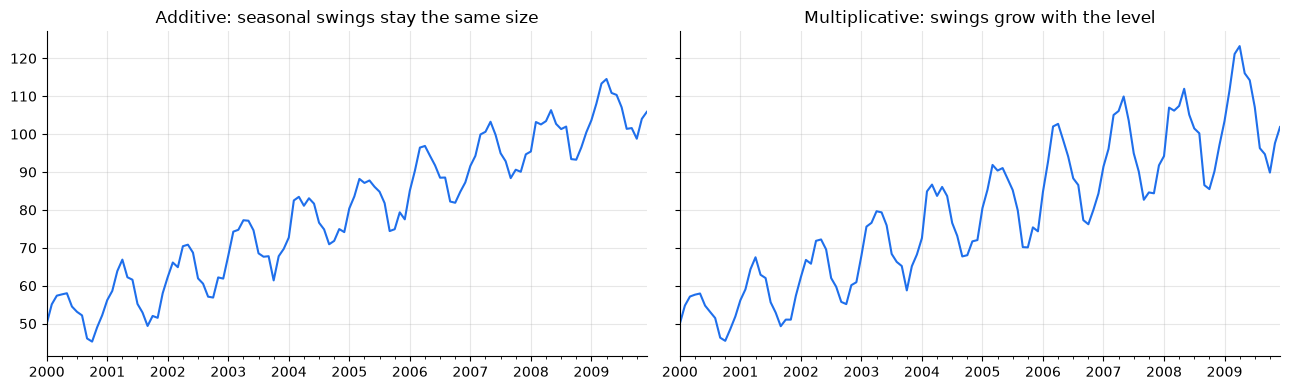

In [2]:
rng = np.random.default_rng(7)
months = pd.date_range("2000-01", periods=120, freq="MS")
t = np.arange(len(months))

true_trend = 50 + 0.5 * t
true_season = np.sin(2 * np.pi * t / 12)        # exactly one cycle every 12 months
noise = rng.normal(0, 1, len(t))

additive = pd.Series(true_trend + 8 * true_season + 2 * noise, index=months)
multiplicative = pd.Series(true_trend * (1 + 0.15 * true_season) * (1 + 0.03 * noise), index=months)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
additive.plot(ax=axes[0], title="Additive: seasonal swings stay the same size")
multiplicative.plot(ax=axes[1], title="Multiplicative: swings grow with the level")
fig.tight_layout();

### The log trick

Taking logs turns products into sums, $\log(T \times S \times R) = \log T + \log S + \log R$, so **a multiplicative series becomes additive on the log scale**. We can check this numerically: the peak-to-trough range within each year should grow on the original scale and stay roughly constant on the log scale.

In [3]:
def yearly_range(s):
    return s.groupby(s.index.year).agg(lambda x: x.max() - x.min())

pd.DataFrame({
    "original scale": yearly_range(multiplicative),
    "log scale": yearly_range(np.log(multiplicative)),
}).T

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009
original scale,12.49,18.18,17.06,20.89,18.95,21.76,26.48,27.25,26.46,33.37
log scale,0.24,0.31,0.27,0.30,0.25,0.27,0.30,0.28,0.27,0.32


On the original scale the yearly swing nearly triples. On the log scale it stays roughly flat. This is why logs are one of the most common first steps in time-series work. We'll use them for PM2.5 too: chapter 01 showed its severe episodes stretch the upper tail far beyond the typical level.

---
## 3. Classical decomposition, from scratch

Classical decomposition is the oldest method, and it's simple enough to write in a dozen lines. For an additive series with period $m$:

1. **Trend.** Take a centred moving average spanning exactly one period, so every season is weighted equally and the seasonality averages out.
2. **Detrend.** Subtract the trend: $y_t - \hat T_t$.
3. **Seasonal.** For each position in the cycle (every January, every February, …), average the detrended values. Shift the averages so they sum to zero over one cycle, so they only redistribute the level, never change it.
4. **Remainder.** Whatever is left: $\hat R_t = y_t - \hat T_t - \hat S_t$.

Step 1 has a wrinkle when $m$ is even. A 12-month window has no middle month, so a plain 12-point average sits between two time points. The standard fix is a **2×12 moving average**: 13 points, with half weight on the two ends. It's centred exactly and still gives each calendar month a total weight of 1/12.

In [4]:
def centred_moving_average(y, period):
    """Moving average spanning exactly one period, centred on each point."""
    if period % 2:
        weights = np.ones(period) / period
    else:
        weights = np.r_[0.5, np.ones(period - 1), 0.5] / period
    return y.rolling(len(weights), center=True).apply(lambda w: w @ weights, raw=True)


def classical_decompose(y, period):
    """Additive classical decomposition. Returns observed, trend, seasonal, remainder."""
    trend = centred_moving_average(y, period)
    detrended = y - trend

    position = np.arange(len(y)) % period
    seasonal_means = detrended.groupby(position).mean()
    seasonal_means -= seasonal_means.mean()            # effects sum to zero over a cycle
    seasonal = pd.Series(seasonal_means.to_numpy()[position], index=y.index)

    return pd.DataFrame({
        "observed": y,
        "trend": trend,
        "seasonal": seasonal,
        "remainder": y - trend - seasonal,
    })


ours = classical_decompose(additive, period=12)
ours.head(8)

,observed,trend,seasonal,remainder
2000-01-01,50.00,NaN,-0.27,NaN
2000-02-01,55.10,NaN,4.32,NaN
2000-03-01,57.38,NaN,6.77,NaN
2000-04-01,57.72,NaN,7.48,NaN
2000-05-01,58.02,NaN,6.70,NaN
2000-06-01,54.52,NaN,4.14,NaN
2000-07-01,53.12,52.81,-0.60,0.91
2000-08-01,52.18,53.22,-2.39,1.35


The first and last six trend values are `NaN`: a centred window spanning a year needs six months on each side. Remember this. It means classical decomposition says nothing about the trend at **the most recent end of the series**, which is exactly where a forecaster cares most.

Now plot the estimates against the truth we built in.

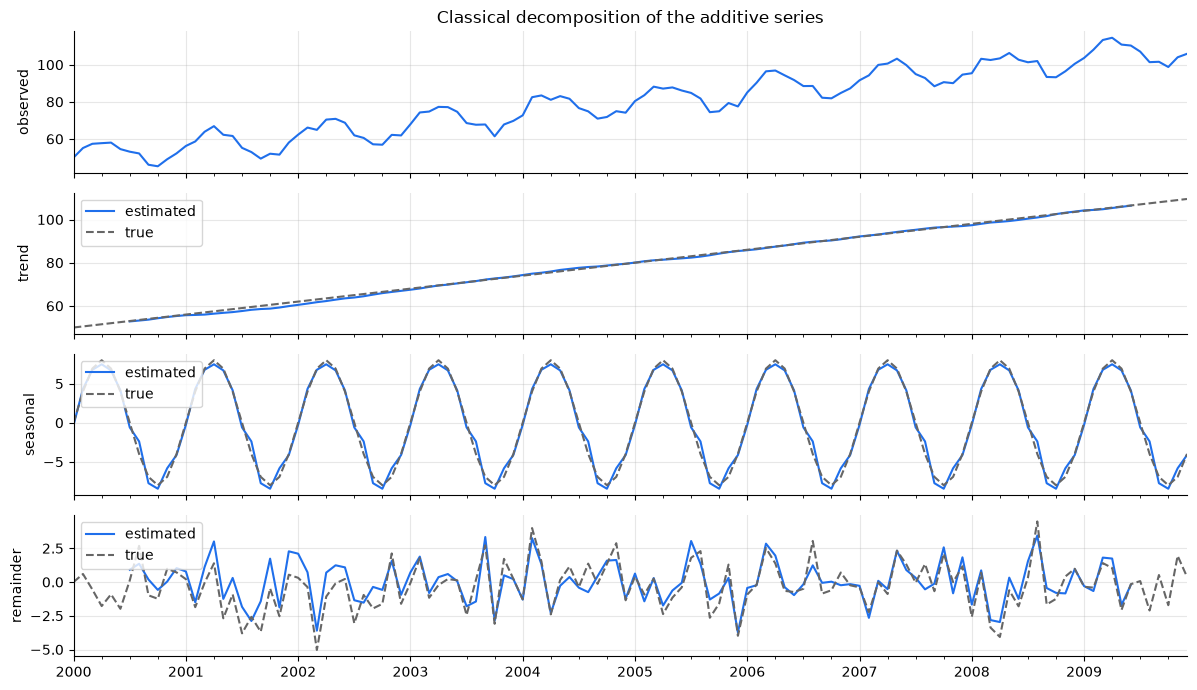

In [5]:
def plot_components(parts, truth=None, title=None):
    fig, axes = plt.subplots(len(parts.columns), 1, figsize=(12, 7), sharex=True)
    for ax, name in zip(axes, parts.columns):
        parts[name].plot(ax=ax, label="estimated")
        if truth is not None and name in truth:
            pd.Series(truth[name], index=parts.index).plot(ax=ax, ls="--", color="0.4", label="true")
            ax.legend(loc="upper left")
        ax.set_ylabel(name)
    if title:
        axes[0].set_title(title)
    fig.tight_layout()

plot_components(ours,
                truth={"trend": true_trend, "seasonal": 8 * true_season, "remainder": 2 * noise},
                title="Classical decomposition of the additive series")

The trend and seasonal estimates track the truth closely. The estimated remainder is close to the noise we added, apart from the missing values at the ends.

### Check against the library

It's good practice to check a hand-written method against a trusted implementation. statsmodels' `seasonal_decompose` is classical decomposition too, so the two should agree to floating-point precision.

In [6]:
library = seasonal_decompose(additive, model="additive", period=12)

print("trend matches:   ", np.allclose(ours["trend"], library.trend, equal_nan=True))
print("seasonal matches:", np.allclose(ours["seasonal"], library.seasonal))

trend matches:    True
seasonal matches: True


With the mechanics understood, we'll use the library version from here on.

---
## 4. When the model type is wrong

What happens if we decompose the **multiplicative** series with an **additive** model? The seasonal step averages each month's swing across all ten years, so it finds a single mid-sized pattern. Early years have smaller swings than that and late years have larger ones, and the difference leaks into the remainder.

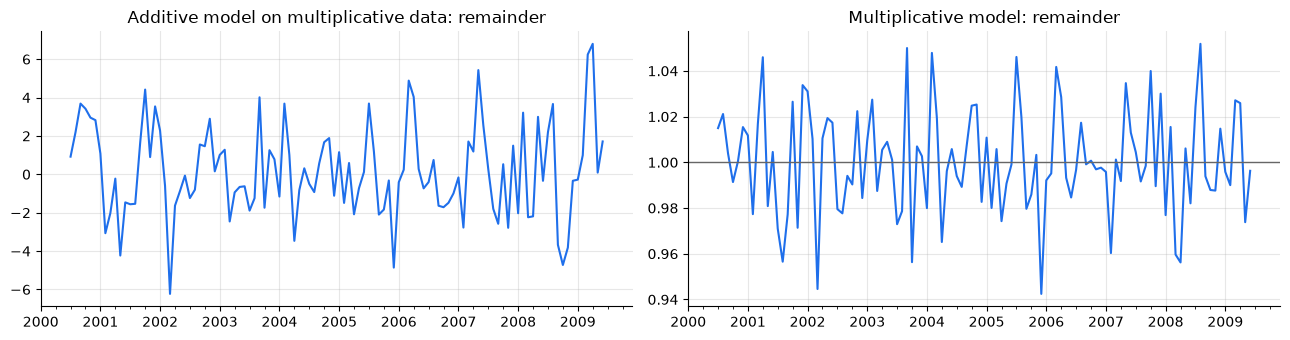

In [7]:
wrong = seasonal_decompose(multiplicative, model="additive", period=12)
right = seasonal_decompose(multiplicative, model="multiplicative", period=12)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5), sharex=True)
wrong.resid.plot(ax=axes[0], title="Additive model on multiplicative data: remainder")
right.resid.plot(ax=axes[1], title="Multiplicative model: remainder")
axes[1].axhline(1, color="0.4", lw=1)
fig.tight_layout();

The left remainder still carries a **seasonal wave that gets larger towards the end**, where the true swings are biggest. That's a sign structure was left behind. The right one looks like patternless noise around 1, because in a multiplicative decomposition the remainder is a *ratio*. The seasonal component becomes ratios too: factors around 1, with each month's factor saying "this month runs X% above or below trend".

In [8]:
right.seasonal.iloc[:12].round(3)

2000-01-01    0.99
2000-02-01    1.08
2000-03-01    1.13
2000-04-01    1.14
2000-05-01    1.13
2000-06-01    1.08
2000-07-01    0.99
2000-08-01    0.95
2000-09-01    0.86
2000-10-01    0.84
2000-11-01    0.88
2000-12-01    0.92
Freq: MS, Name: seasonal, dtype: float64

> **Diagnostic habit:** after any decomposition, look at the remainder. If you can still see seasonality, a trend, or swings that change size, the decomposition hasn't finished the job.

---
## 5. Limits of classical decomposition

Classical decomposition is transparent, but it makes strong assumptions:

1. **The seasonal pattern never changes.** Every January gets the same effect, from the first year to the last.
2. **No trend estimate at the ends.** That's `period // 2` points missing at each end.
3. **Outliers spread.** One wild value distorts the moving-average trend over a whole period, and the seasonal average for its month in every year.
4. **One seasonal period only.** Hourly data with daily *and* yearly cycles doesn't fit.

A real dataset shows the first problem clearly. The Mauna Loa CO₂ record is one of the most famous series in science: continuous air samples taken on a Hawaiian volcano since 1958.

> Keeling, C.D. and T.P. Whorf (2004). *Atmospheric CO₂ concentrations derived from flask air samples at sites in the SIO network.* In *Trends: A Compendium of Data on Global Change*, CDIAC, Oak Ridge National Laboratory. Public domain; shipped with statsmodels as `sm.datasets.co2`.

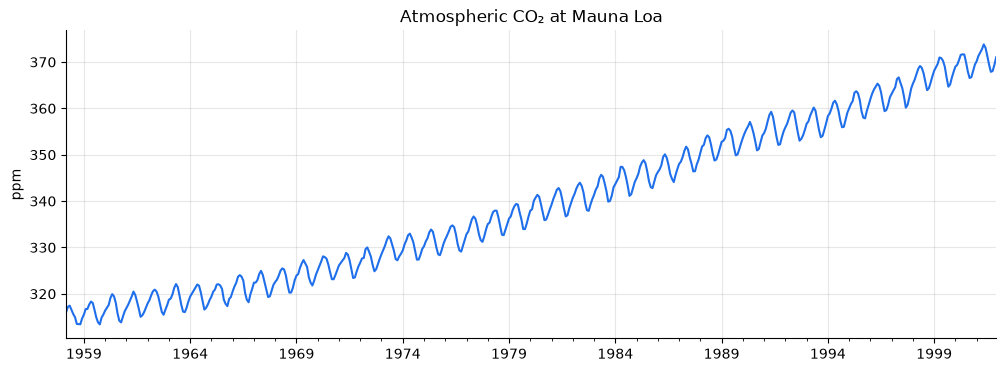

In [9]:
co2_weekly = sm.datasets.co2.load_pandas().data["co2"]
co2 = co2_weekly.resample("MS").mean().interpolate()   # monthly, filling a handful of gaps

co2.plot(title="Atmospheric CO₂ at Mauna Loa", ylabel="ppm");

Rising trend, regular yearly wiggle. It's the textbook additive series. The wiggle comes from the Northern Hemisphere's plants drawing CO₂ down each summer and releasing it each winter. But is the wiggle really constant?

---
## 6. STL: seasonal decomposition that can evolve

**STL** (*Seasonal-Trend decomposition using LOESS*; Cleveland et al., 1990) replaces the moving averages with **local regression** (LOESS) smoothers, fitted over and over. Compared with the classical method:

- the seasonal pattern may **change slowly over time**
- it gives estimates **right up to the ends** of the series
- with `robust=True` it **down-weights outliers**, so they stay in the remainder instead of spreading
- the period can be any integer ≥ 2

Its main settings are the smoother window lengths: `seasonal` controls how quickly the seasonal pattern may change, and `trend` controls how smooth the trend is. The defaults are a reasonable start.

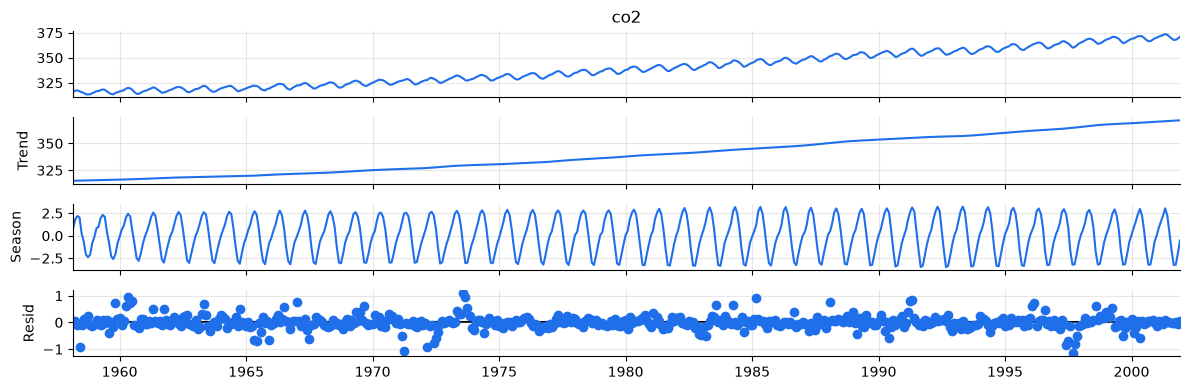

In [10]:
co2_stl = STL(co2, period=12, robust=True).fit()
co2_stl.plot();

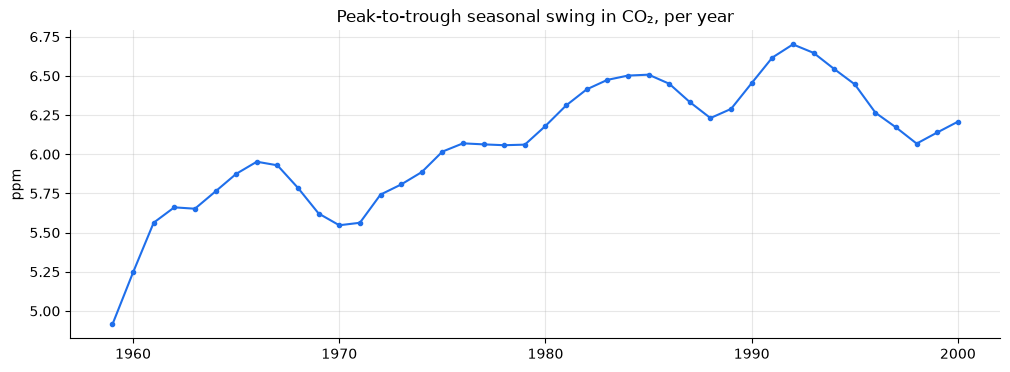

In [11]:
yearly_swing = yearly_range(co2_stl.seasonal)
ax = yearly_swing.iloc[1:-1].plot(marker=".", title="Peak-to-trough seasonal swing in CO₂, per year")
ax.set_ylabel("ppm");

The seasonal swing is **not constant**. It widens by more than 1 ppm between the early 1960s and the early 1990s, with slower wobbles along the way. Classical decomposition would have forced a single average swing onto every year. STL lets the pattern drift, and the drift is itself a scientific finding.

### Robustness to outliers

Now we corrupt one month with a large spike, as a faulty sensor or data-entry error would, and compare how each method copes.

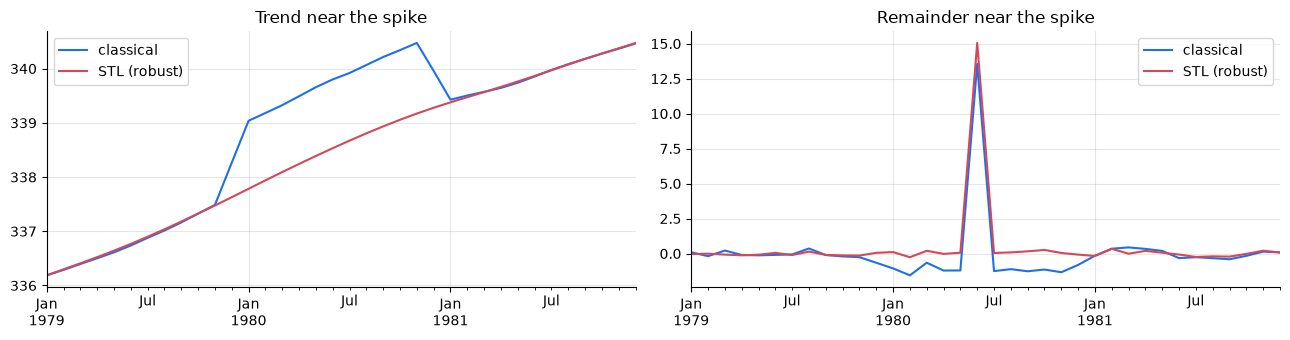

In [12]:
corrupted = co2.copy()
corrupted.loc["1980-06-01"] += 15

classical = seasonal_decompose(corrupted, model="additive", period=12)
robust = STL(corrupted, period=12, robust=True).fit()

window = slice("1979-01", "1981-12")
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
for ax, part, title in [(axes[0], "trend", "Trend near the spike"),
                        (axes[1], "resid", "Remainder near the spike")]:
    getattr(classical, part)[window].plot(ax=ax, label="classical")
    getattr(robust, part)[window].plot(ax=ax, label="STL (robust)")
    ax.set_title(title)
    ax.legend()
fig.tight_layout();

The classical trend bulges for a whole year around the spike. Its seasonal averages absorb part of the spike as well, so a fake June effect gets added to every year in the record. Robust STL leaves the trend almost untouched and puts the spike into the remainder, where it belongs **and where you can find it**. Large remainder values from a robust decomposition make a simple, effective anomaly detector.

---
## 7. Finding the period: the periodogram

Every method so far needed the period up front: 12 for monthly data, 24 for hourly. When you don't know it, the **periodogram** can find it. It splits a series' variance by **frequency**: how much of the ups and downs comes from waves that repeat every 2 steps, every 3, …, every $n$. A strong seasonal cycle shows up as a tall peak at its frequency, $1/\text{period}$. This is the Fourier idea again, used in reverse: instead of building a seasonal curve from sines and cosines, we measure which sines and cosines the data contains.

`scipy.signal.periodogram` does the computation. We'll start with CO₂, taking a first difference to remove the trend, which would otherwise swamp everything else (more on that in a moment).

,power
period (months),
11.9,452.30
6.0,61.91
6.0,55.74
12.2,43.14


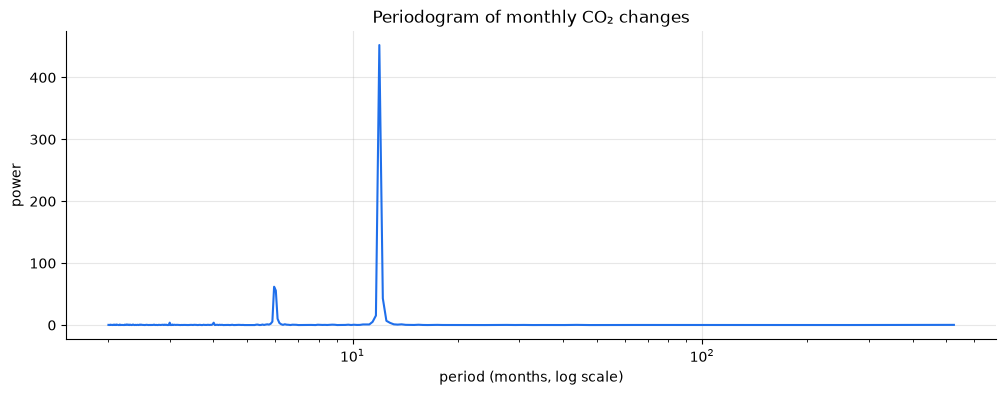

In [13]:
from scipy.signal import periodogram

def strongest_periods(series, n=4):
    # periods (in steps) with the most power, plus the whole (period -> power) curve
    freq, power = periodogram(np.asarray(series, dtype=float) - np.mean(series))
    freq, power = freq[1:], power[1:]                       # drop frequency 0 (the mean)
    order = np.argsort(power)[::-1][:n]
    return pd.Series(power[order], index=np.round(1 / freq[order], 1)), pd.Series(power, index=1 / freq)

co2_top, co2_curve = strongest_periods(co2.diff().dropna())

ax = co2_curve.plot(logx=True, title="Periodogram of monthly CO₂ changes")
ax.set(xlabel="period (months, log scale)", ylabel="power")
co2_top.rename("power").rename_axis("period (months)").to_frame()

The tallest peak is at **12 months**, the annual cycle, found without being told. The next is at **6 months**, a **harmonic**. The annual wave isn't a pure sine (CO₂ falls quickly and recovers slowly, as chapter 08 revisits), and describing a lopsided wave takes a 6-month component as well.

### A warning from hourly PM2.5

Now the hourly Beijing series. We expect a daily cycle (chapter 01), so the periodogram should peak at 24 hours. Let's compare the raw log series with its first difference.

,raw series: top periods (h),differenced: top periods (h)
0,389.3,24.0
1,184.4,12.0
2,2920.0,23.9
3,182.5,6.0
4,269.5,8.8
5,24.0,4.2


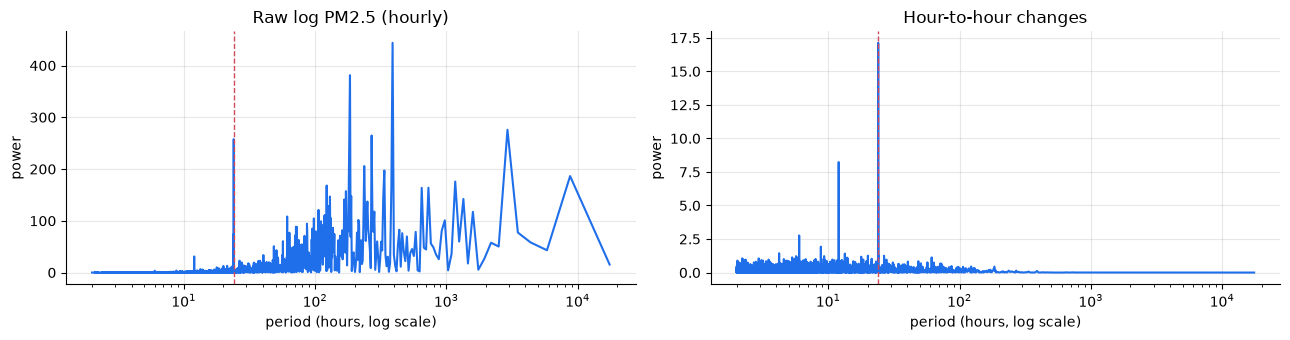

In [14]:
hourly_log = np.log(tsutils.load_beijing()["pm25"].loc["2013":"2014"]
                    .interpolate(method="time", limit_direction="both"))

raw_top, raw_curve = strongest_periods(hourly_log, n=6)
diff_top, diff_curve = strongest_periods(hourly_log.diff().dropna(), n=6)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
raw_curve.plot(ax=axes[0], logx=True, title="Raw log PM2.5 (hourly)")
diff_curve.plot(ax=axes[1], logx=True, title="Hour-to-hour changes")
for ax in axes:
    ax.axvline(24, color="#d1495b", ls="--", lw=1)
    ax.set(xlabel="period (hours, log scale)", ylabel="power")
fig.tight_layout()

pd.DataFrame({"raw series: top periods (h)": raw_top.index, "differenced: top periods (h)": diff_top.index})

On the **raw** series, the top periods are mostly **long**: waves lasting days to weeks, the rhythm of smog episodes building and clearing. The 24-hour cycle is there, but it's buried among them. A persistent series puts most of its variance at **low frequencies**, a so-called *red* spectrum, and that can hide a genuine seasonal peak.

**Differencing** acts as a filter that removes slow wandering, and the picture flips: **24 hours** comes out on top, followed by **12 hours**, its harmonic. It's the daily cycle from chapter 01, found from the data alone.

Two lessons:
- **Remove trend and slow persistence before looking for seasonal peaks**, by differencing or by working on a decomposition's remainder.
- **Not every peak is a season.** The long "periods" in the raw spectrum are episodes of varying length, *cycles* in section 1's sense, not a fixed calendar rhythm. Confirm any candidate period with domain knowledge and a plot before building it into a model.

---
## 8. How strong is each component?

Decomposition always *produces* a trend and a seasonal component, even for pure noise. To know whether they mean anything, we compare their variance with the remainder's. For a decomposition $y_t = T_t + S_t + R_t$ (Wang, Smith & Hyndman, 2006):

$$F_T = \max\left(0,\; 1 - \frac{\operatorname{Var}(R_t)}{\operatorname{Var}(T_t + R_t)}\right) \qquad F_S = \max\left(0,\; 1 - \frac{\operatorname{Var}(R_t)}{\operatorname{Var}(S_t + R_t)}\right)$$

Both measures run from 0 to 1. A value near 1 means the component dominates the remainder. A value near 0 means the "component" is indistinguishable from noise.

In [15]:
def component_strength(trend, seasonal, remainder):
    var_r = np.nanvar(remainder)
    return pd.Series({
        "trend strength": max(0.0, 1 - var_r / np.nanvar(trend + remainder)),
        "seasonal strength": max(0.0, 1 - var_r / np.nanvar(seasonal + remainder)),
    })

synthetic_stl = STL(additive, period=12, robust=True).fit()
component_strength(synthetic_stl.trend, synthetic_stl.seasonal, synthetic_stl.resid)

trend strength       0.99
seasonal strength    0.94
dtype: float64

### Back to Beijing

Now for our running dataset. Six years of data contain only **six annual cycles**. That's too few for a daily-resolution decomposition to separate a stable yearly pattern from individual smog episodes: the seasonal component would simply memorise them. So we decompose **monthly means**. Because chapter 01 found heavy upper tails, we use the **log** scale.

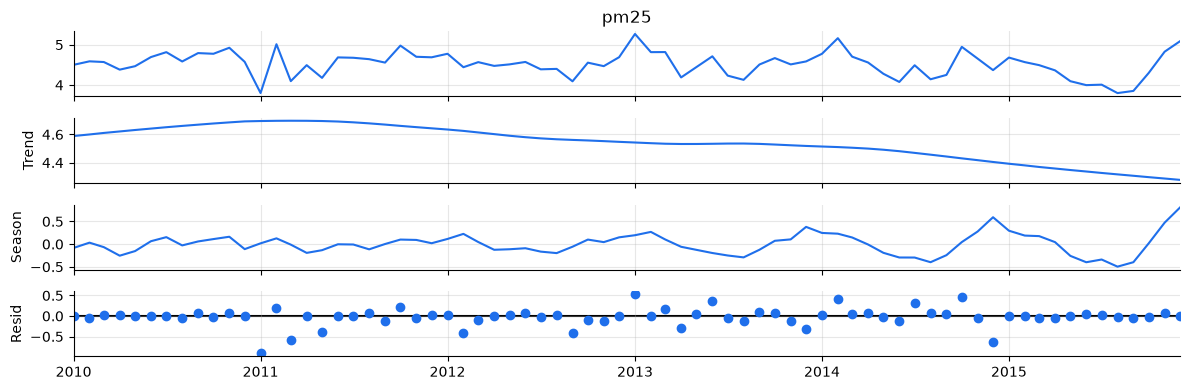

In [16]:
pm = tsutils.load_beijing()["pm25"].interpolate(method="time", limit=3, limit_area="inside")
pm_monthly_log = np.log(pm.resample("MS").mean())

pm_stl = STL(pm_monthly_log, period=12, robust=True).fit()
pm_stl.plot();

In [17]:
pd.DataFrame({
    "CO₂ (monthly)": component_strength(co2_stl.trend, co2_stl.seasonal, co2_stl.resid),
    "PM2.5 (monthly, log)": component_strength(pm_stl.trend, pm_stl.seasonal, pm_stl.resid),
}).T

,trend strength,seasonal strength
CO₂ (monthly),1.00,0.98
"PM2.5 (monthly, log)",0.12,0.47


The contrast is striking. CO₂ is almost pure trend and seasonality: once you know the date, you nearly know the value. PM2.5 has a **real but modest** seasonal pattern (higher in the heating months, lower in late summer). Most of its month-to-month variation sits in the remainder, which here means weather-driven episodes that no calendar can predict.

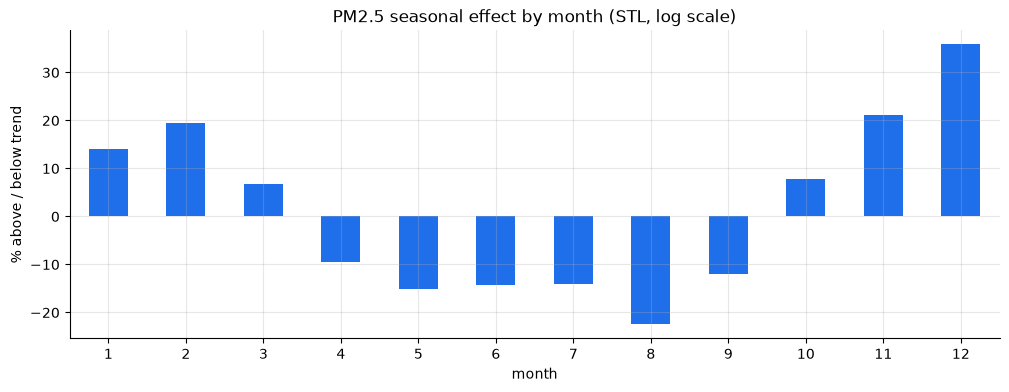

In [18]:
seasonal_effect = np.exp(pm_stl.seasonal.groupby(pm_stl.seasonal.index.month).mean())
ax = ((seasonal_effect - 1) * 100).plot(kind="bar", rot=0, title="PM2.5 seasonal effect by month (STL, log scale)")
ax.set(xlabel="month", ylabel="% above / below trend");

Because we decomposed on the log scale, $e^{S_t}$ is a **multiplicative factor**. The bar chart reads directly as "this month typically runs X% above or below the trend".

This sets expectations for the rest of the course. **A method can only forecast the structure that's actually there.** Seasonal methods will do very well on CO₂. For PM2.5, the value of any model will depend on how well it tracks the *recent level* and, later, on *weather inputs*, far more than on the calendar.

> **Multiple seasonalities.** Hourly PM2.5 has a daily cycle *and* a yearly one. statsmodels' `MSTL` extends STL to several periods at once, e.g. `MSTL(y, periods=(24, 24 * 365))`, but it needs at least two full cycles of the longest period. We'll return to multiple seasonalities in the Prophet chapter, which handles them natively.

---
## Exercises

### Exercise 1: Temperature vs. pollution
Resample Beijing's hourly `temp` column to daily means and decompose it with STL (`period=365`). Six cycles is fine here, because temperature's yearly pattern is very regular. Compute trend and seasonal strength. How do they compare with PM2.5, and what does that tell you about which of the two series the calendar alone can forecast?

<details><summary>Solution</summary>

```python
temp_daily = tsutils.load_beijing()["temp"].resample("D").mean().interpolate()
temp_stl = STL(temp_daily, period=365, robust=True).fit()
temp_stl.plot()
component_strength(temp_stl.trend, temp_stl.seasonal, temp_stl.resid)
```
Temperature's seasonal strength is close to 1, and its trend strength is near zero because six years show no meaningful warming or cooling. Knowing the day of the year tells you most of what there is to know about temperature, and much less about PM2.5.
</details>

### Exercise 2: The wrong period
Decompose the synthetic `additive` series with `seasonal_decompose` using `period=6` and then `period=10` instead of 12. Plot the remainder each time. How could you spot a wrong period if you *didn't* know the truth?

<details><summary>Solution</summary>

```python
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
for ax, p in zip(axes, [6, 10, 12]):
    seasonal_decompose(additive, period=p).resid.plot(ax=ax, title=f"remainder, period={p}")
fig.tight_layout()
```
With the wrong period, the true yearly cycle can't be absorbed by the seasonal component, so it shows up as a clear repeating wave in the remainder, and the remainder's variance is much larger than with the correct period. Checking the remainder, and comparing `resid.var()` across candidate periods, exposes the mistake. Chapter 06's autocorrelation plots will give a more direct way to find the period.
</details>

### Exercise 3: Multiplicative classical decomposition by hand
Adapt `classical_decompose` into `classical_decompose_mult`: divide instead of subtracting, and normalise the seasonal factors so they **average to 1** over a cycle. Check your result against `seasonal_decompose(multiplicative, model="multiplicative", period=12)`.

<details><summary>Solution</summary>

```python
def classical_decompose_mult(y, period):
    trend = centred_moving_average(y, period)
    ratio = y / trend
    position = np.arange(len(y)) % period
    factors = ratio.groupby(position).mean()
    factors /= factors.mean()                       # factors average to 1
    seasonal = pd.Series(factors.to_numpy()[position], index=y.index)
    return pd.DataFrame({"observed": y, "trend": trend,
                         "seasonal": seasonal, "remainder": y / (trend * seasonal)})

mine = classical_decompose_mult(multiplicative, 12)
lib = seasonal_decompose(multiplicative, model="multiplicative", period=12)
print(np.allclose(mine["seasonal"], lib.seasonal),
      np.allclose(mine["trend"], lib.trend, equal_nan=True))
```
</details>

### Exercise 4: Build an anomaly detector
Using robust STL on the `corrupted` CO₂ series from section 6, flag every month whose remainder is more than 4 robust standard deviations from zero. Use $1.4826 \times \text{median}(|R_t|)$ as the robust standard deviation. It's a common choice because, unlike `std()`, one large outlier can't inflate it.
1. Does the rule find the spike you injected?
2. How many *other* months does it flag, and how big are they compared with the spike?
3. What does that tell you about choosing a threshold?

<details><summary>Solution</summary>

```python
resid = robust.resid
robust_sd = 1.4826 * resid.abs().median()
flagged = resid[resid.abs() > 4 * robust_sd]
print(f"robust sd: {robust_sd:.2f} ppm, months flagged: {len(flagged)}")
flagged.abs().sort_values(ascending=False).head()
```
The spike (June 1980, about 15 ppm) is flagged, but so are roughly thirty genuine months. STL fits CO₂ so closely that the robust standard deviation is only about 0.15 ppm, so ordinary wobbles of 0.6–1 ppm clear a 4σ bar. Sorting by size shows the spike is more than **ten times** larger than anything else. A person spots it at once. The fixed rule doesn't.

The lesson: a "k standard deviations" rule assumes roughly normal, independent residuals, and real remainders rarely are. Look at the **ranked** residuals and set the threshold for your purpose, based on how many false alarms you can tolerate, rather than trusting a textbook k.
</details>

---
## Key takeaways

- A series can be described as **trend + seasonality + remainder**, combined additively or multiplicatively. Seasonality has a **fixed period**; cycles don't.
- **Swings that grow with the level** signal multiplicative structure. A **log** transform turns it additive.
- Classical decomposition is simple: moving-average trend, averaged seasonal effects. But it assumes a fixed seasonal pattern, loses the ends, and spreads outliers.
- **STL** allows evolving seasonality, covers the whole series and, with `robust=True`, isolates outliers in the remainder.
- The **periodogram** finds seasonal periods from the data, but difference or detrend first, because persistence buries seasonal peaks under low-frequency power.
- Always inspect the **remainder**, and measure **component strength**. Decomposition will invent components in pure noise if you let it.
- CO₂ is nearly all trend and season. PM2.5 is mostly remainder: its forecastability depends on dynamics and weather, not the calendar.

**Next:** *03 · Stationarity*. Most classical forecasting models need a series whose statistical behaviour doesn't drift over time. We'll learn what that means precisely, how to test for it, and how to get there.